In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.listdir('/content'))
print(os.path.getsize('/content/fraudTrain.csv') / (1024*1024), "MB")
print(os.path.getsize('/content/fraudTest.csv') / (1024*1024), "MB")

['.config', 'fraudTest.csv', 'fraudTrain.csv', 'sample_data']
14.0 MB
14.0 MB


In [ ]:
# Robust read: tolerate a few bad rows instead of crashing outright
df_train = pd.read_csv('/content/fraudTrain.csv', index_col=0, on_bad_lines='warn', engine='python')
df_test  = pd.read_csv('/content/fraudTest.csv', index_col=0, on_bad_lines='warn', engine='python')

df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
print(df.shape)
df.head()

/tmp/ipykernel_2709/2001783812.py:2: ParserWarning: Skipping line 54486: unexpected end of data

  df_train = pd.read_csv('/content/fraudTrain.csv', index_col=0, on_bad_lines='warn', engine='python')


(108933, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


In [ ]:
# Clean up any rows corrupted by parsing (missing label or missing key features)
print("NaNs per column before cleanup:")
print(df.isna().sum()[df.isna().sum() > 0])

df = df.dropna(subset=['is_fraud'])
df['is_fraud'] = df['is_fraud'].astype(int)
df = df.dropna()   # drop any remaining rows with corrupted/missing fields

print("Shape after cleanup:", df.shape)
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True) * 100)

NaNs per column before cleanup:
unix_time     1
merch_lat     1
merch_long    1
is_fraud      1
dtype: int64
Shape after cleanup: (108932, 22)
is_fraud
0    108182
1       750
Name: count, dtype: int64
is_fraud
0    99.311497
1     0.688503
Name: proportion, dtype: float64


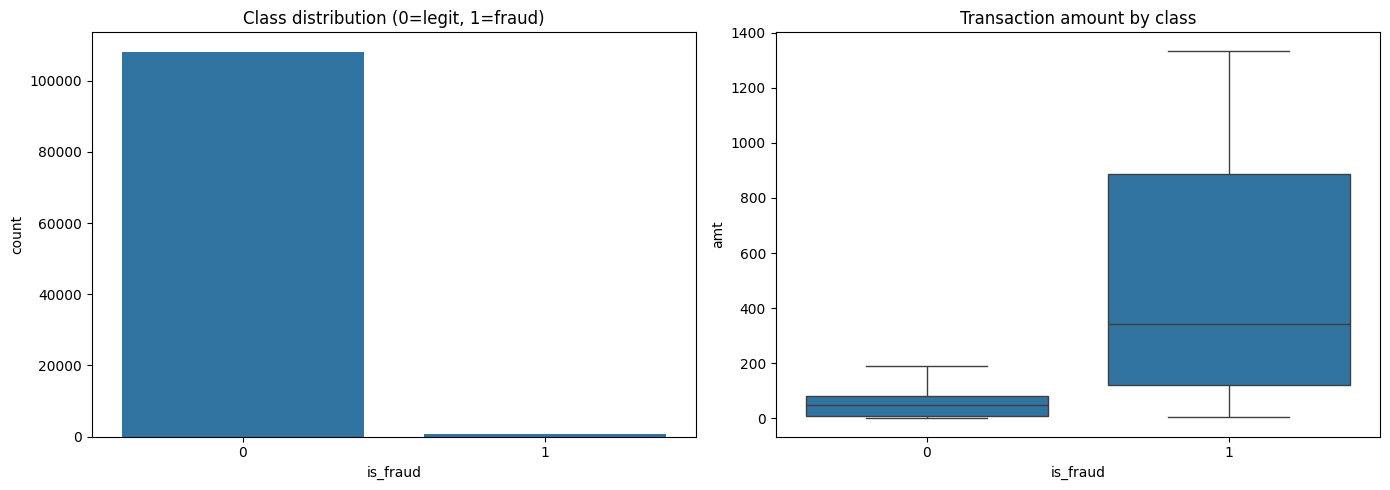

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='is_fraud', data=df, ax=axes[0])
axes[0].set_title('Class distribution (0=legit, 1=fraud)')
sns.boxplot(x='is_fraud', y='amt', data=df, ax=axes[1], showfliers=False)
axes[1].set_title('Transaction amount by class')
plt.tight_layout()
plt.show()

category
shopping_net      0.018632
grocery_pos       0.017487
misc_net          0.015807
shopping_pos      0.008778
travel            0.005033
gas_transport     0.005013
misc_pos          0.004357
grocery_net       0.003732
kids_pets         0.003464
personal_care     0.002957
entertainment     0.002913
food_dining       0.002294
home              0.002129
health_fitness    0.002038
Name: is_fraud, dtype: float64


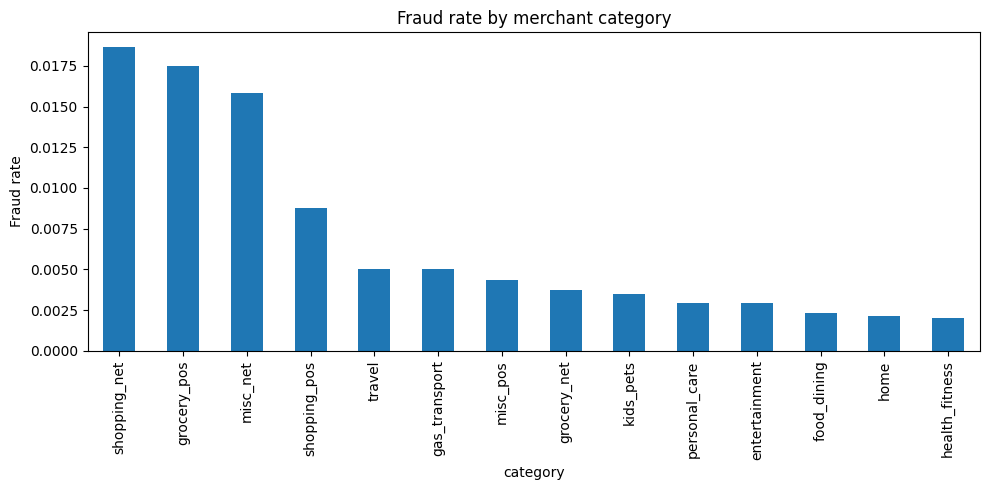

In [ ]:
fraud_by_cat = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
print(fraud_by_cat)

plt.figure(figsize=(10, 5))
fraud_by_cat.plot(kind='bar')
plt.ylabel('Fraud rate')
plt.title('Fraud rate by merchant category')
plt.tight_layout()
plt.show()

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Drop any rows where date parsing failed
df = df.dropna(subset=['hour', 'day_of_week', 'month', 'age', 'distance_km'])

drop_cols = [
    'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last',
    'street', 'city', 'state', 'zip', 'dob', 'trans_num', 'unix_time',
    'lat', 'long', 'merch_lat', 'merch_long', 'job'
]
df_model = df.drop(columns=drop_cols)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(df_model.shape)
print("Any NaNs left?", df_model.isna().sum().sum())

Categorical columns to encode: ['category', 'gender']
(108932, 22)
Any NaNs left? 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print("Fraud rate - train:", y_train.mean(), " test:", y_test.mean())

(87145, 21) (21787, 21)
Fraud rate - train: 0.0068850765964771354  test: 0.006884839583237711


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained[name] = model
print("Done.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Done.



===== Logistic Regression =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.88      0.94     21637
       Fraud       0.04      0.76      0.08       150

    accuracy                           0.88     21787
   macro avg       0.52      0.82      0.51     21787
weighted avg       0.99      0.88      0.93     21787

ROC-AUC: 0.9139

===== Decision Tree =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     21637
       Fraud       0.18      0.93      0.31       150

    accuracy                           0.97     21787
   macro avg       0.59      0.95      0.65     21787
weighted avg       0.99      0.97      0.98     21787

ROC-AUC: 0.9557

===== Random Forest =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     21637
       Fraud       0.61      0.83      0.70       150

    accuracy                           1.00     21787
   macro 

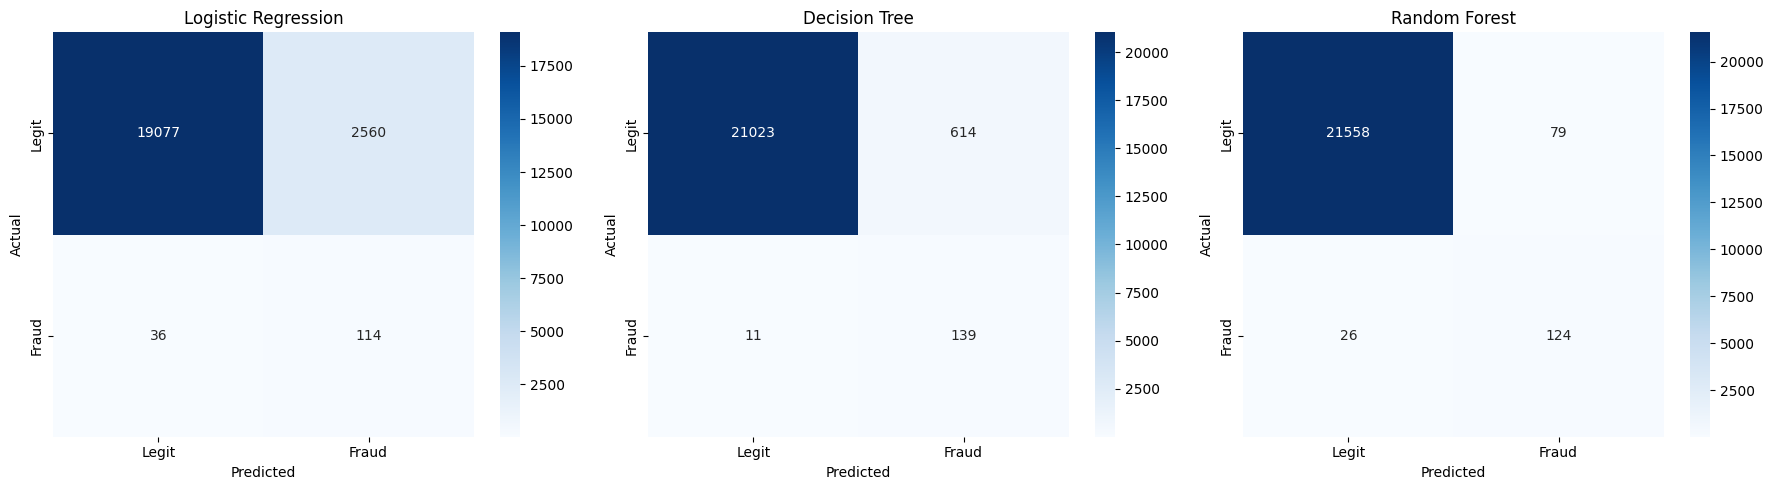

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained.items()):
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    print(f"ROC-AUC: {auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

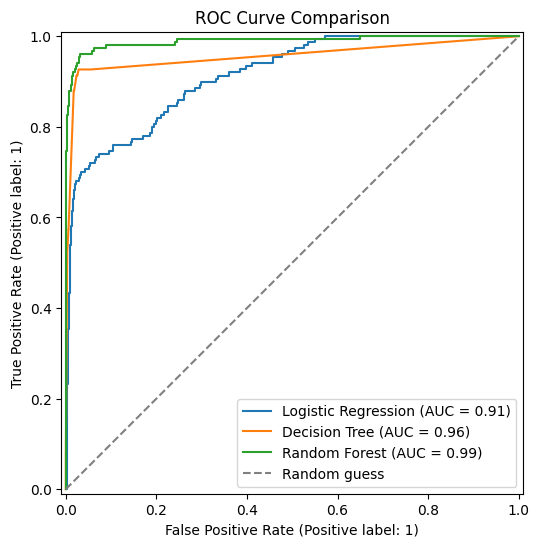

,Model,ROC-AUC
2,Random Forest,0.988798
1,Decision Tree,0.955706
0,Logistic Regression,0.913883


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in trained.items():
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    RocCurveDisplay.from_estimator(model, X_eval, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'ROC-AUC']).sort_values('ROC-AUC', ascending=False)
results_df

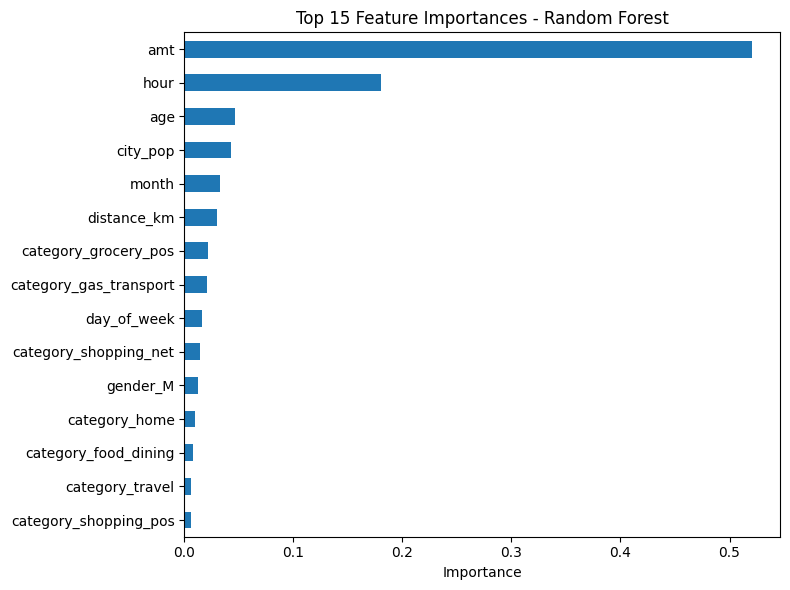

In [ ]:
importances = pd.Series(trained["Random Forest"].feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()